# EDA and Data Collection

Since there are lectures posted online with automatically generated captions let's try to build knowledge graph using them. 


In this notebook I prepare the raw text corpus and make the first exploratory analysis before building the knowledge graph. I use the course transcripts as the corpus because they are already raw text, domain-specific, and naturally contain graph concepts, methods, tools, examples, and applications.

## 1. Dataset Choice

I compare two real corpora:

- **course transcripts**: noisy spoken text from the course, useful for a course-specific SNA concept graph;
- **Wikipedia pages about network science**: cleaner encyclopedia text, useful as a second baseline corpus.

The datasets are loaded into one technical table only for convenience, but all main EDA steps below are calculated separately for each corpus.


In [17]:
%pip install -q pandas matplotlib networkx requests scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [18]:
import json
import re
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import requests
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

plt.style.use("seaborn-v0_8-whitegrid")

project_dir = Path.cwd().parent if Path.cwd().name == "work" else Path.cwd()
course_dir = project_dir / "course materials"


transcript_files = sorted(course_dir.glob("*_transcript.md"))
transcript_files


[PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/01_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/02_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/03_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/04_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/05_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/06_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/07_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/08_transcript.md')]

## 2. Data Collection

Both datasets are converted to the same table format: `document_id`, `corpus`, `source_file`, `speaker`, `text`, `words`, `chars`. For transcripts, `speaker` is the real speaker from the transcript. For Wikipedia, `speaker` is set to `Wikipedia`.


In [19]:
def parse_transcript(path):
    text = path.read_text(encoding="utf-8", errors="ignore")
    pattern = re.compile(r"(?m)^(\d{1,2}:\d{2})\s+-\s+(.+)$")
    matches = list(pattern.finditer(text))
    rows = []

    if not matches:
        rows.append({
            "document_id": path.stem,
            "corpus": "course_transcripts",
            "source_file": path.name,
            "time": None,
            "speaker": "unknown",
            "text": text.strip(),
        })
        return rows

    for i, match in enumerate(matches):
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        rows.append({
            "document_id": f"{path.stem}_{i:03d}",
            "corpus": "course_transcripts",
            "source_file": path.name,
            "time": match.group(1),
            "speaker": match.group(2).strip(),
            "text": text[start:end].strip(),
        })
    return rows


wiki_cache_path = project_dir / "work" / ".wikipedia_pages_cache.json"
if wiki_cache_path.exists():
    wiki_cache = json.loads(wiki_cache_path.read_text(encoding="utf-8"))
else:
    wiki_cache = {}


def fetch_wikipedia_page(title):
    if title in wiki_cache:
        return wiki_cache[title]["title"], wiki_cache[title]["extract"]

    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "prop": "extracts",
        "explaintext": 1,
        "redirects": 1,
        "titles": title,
    }
    headers = {
        "User-Agent": "SNA-Magolego-2026-student-project/1.0 (local educational notebook)",
    }
    response = None
    for attempt in range(3):
        response = requests.get(url, params=params, headers=headers, timeout=20)
        if response.status_code != 429:
            break
        wait_seconds = 5 * (attempt + 1)
        print(f"Wikipedia rate limit for {title!r}. Waiting {wait_seconds}s...")
        time.sleep(wait_seconds)

    response.raise_for_status()
    pages = response.json()["query"]["pages"]
    page = next(iter(pages.values()))
    real_title = page.get("title", title)
    extract = page.get("extract", "")
    wiki_cache[title] = {"title": real_title, "extract": extract}
    wiki_cache_path.write_text(json.dumps(wiki_cache, ensure_ascii=False, indent=2), encoding="utf-8")
    time.sleep(1)
    return real_title, extract


wiki_titles = [
    "Social network analysis",
    "Knowledge graph",
    "Graph theory",
    "Network science",
    "PageRank",
    "Centrality",
    "Community structure",
    "Community search",
    "Graph drawing",
    "Graph neural network",
    "Node2vec",
    "Link prediction",
    "NetworkX",
    "Named-entity recognition",
    "Relation extraction",
]

segments = []
for path in transcript_files:
    segments.extend(parse_transcript(path))

wiki_rows = []
for i, title in enumerate(wiki_titles):
    try:
        real_title, text = fetch_wikipedia_page(title)
    except Exception as error:
        print(f"Could not load Wikipedia page {title!r}: {error}")
        continue

    paragraphs = [p.strip() for p in text.split("\n") if len(p.split()) >= 30]
    for j, paragraph in enumerate(paragraphs):
        wiki_rows.append({
            "document_id": f"wiki_{i:02d}_{j:03d}",
            "corpus": "wikipedia_network_science",
            "source_file": real_title,
            "time": None,
            "speaker": "Wikipedia",
            "text": paragraph,
        })

if not wiki_rows:
    print("Wikipedia corpus was not loaded. The notebook will continue with course transcripts only.")

segments.extend(wiki_rows)
segments_df = pd.DataFrame(segments)
segments_df["text"] = segments_df["text"].fillna("")
segments_df["chars"] = segments_df["text"].str.len()
segments_df["words"] = segments_df["text"].str.findall(r"[A-Za-zА-Яа-я0-9_]+").str.len()
segments_df = segments_df[segments_df["words"] > 5].reset_index(drop=True)

segments_df.head()


Wikipedia rate limit for 'Node2vec'. Waiting 5s...
Wikipedia rate limit for 'Node2vec'. Waiting 10s...


,document_id,corpus,source_file,time,speaker,text,chars,words
0,01_transcript_000,course_transcripts,01_transcript.md,7:33,Ilia Karpov,"Okay, I guess we may start for today. Hello ev...",393,69
1,01_transcript_001,course_transcripts,01_transcript.md,8:42,Qazi Akash Ahmad,We can hear Professor Audible. Absolutely.,42,6
2,01_transcript_002,course_transcripts,01_transcript.md,8:45,Ilia Karpov,"Thank you. Okay. Because the previous year, we...",4232,764
3,01_transcript_003,course_transcripts,01_transcript.md,15:38,Qazi Akash Ahmad,"Hello, professor. Hi. My name is Qazi. I would...",301,59
4,01_transcript_004,course_transcripts,01_transcript.md,15:59,Ilia Karpov,"No, no, no, forget about social networks. What...",153,27


In [20]:
collection_summary = pd.DataFrame({
    "metric": ["source files", "segments", "total words", "total characters"],
    "value": [
        int(segments_df["source_file"].nunique()),
        len(segments_df),
        int(segments_df["words"].sum()),
        int(segments_df["chars"].sum()),
    ],
})

by_corpus = (
    segments_df.groupby("corpus", as_index=False)
    .agg(source_files=("source_file", "nunique"), segments=("document_id", "count"), words=("words", "sum"))
    .sort_values("words", ascending=False)
)

display(collection_summary)
display(by_corpus)


,metric,value
0,source files,23
1,segments,558
2,total words,161968
3,total characters,911384


,corpus,source_files,segments,words
0,course_transcripts,8,111,130226
1,wikipedia_network_science,15,447,31742


## 3. Corpus Structure

Here we check how large the transcript corpus is, which lectures contain more material, and who speaks most often. This is important because the graph may be biased toward the main lecturer and the longest lectures.

,corpus,source_file,segments,words,chars
0,course_transcripts,01_transcript.md,11,20027,109723
1,course_transcripts,02_transcript.md,15,16891,91128
2,course_transcripts,03_transcript.md,34,18981,102461
3,course_transcripts,04_transcript.md,24,16708,92191
4,course_transcripts,05_transcript.md,7,15774,86501
5,course_transcripts,06_transcript.md,1,15635,85848
6,course_transcripts,07_transcript.md,17,12951,71074
7,course_transcripts,08_transcript.md,2,13259,72345
8,wikipedia_network_science,Centrality,42,3172,20038
9,wikipedia_network_science,Community search,7,573,3705


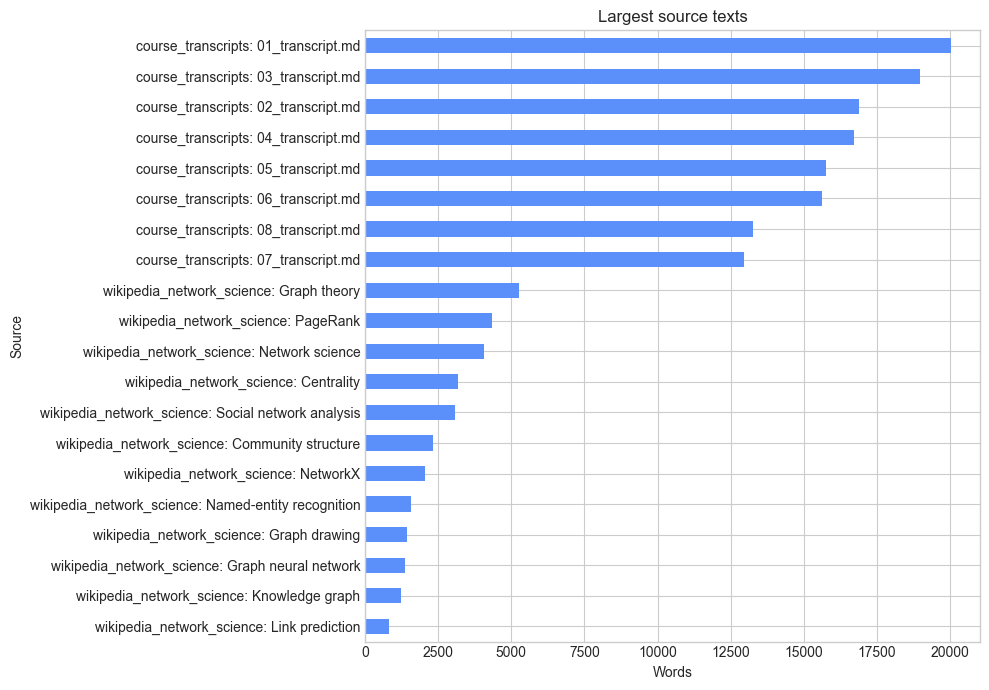

In [21]:
by_file = (
    segments_df.groupby(["corpus", "source_file"], as_index=False)
    .agg(segments=("document_id", "count"), words=("words", "sum"), chars=("chars", "sum"))
    .sort_values(["corpus", "source_file"])
)

display(by_file)

plot_df = by_file.sort_values("words", ascending=False).head(20).copy()
plot_df["label"] = plot_df["corpus"] + ": " + plot_df["source_file"]

ax = plot_df.sort_values("words").plot.barh(x="label", y="words", legend=False, figsize=(10, 7), color="#5B8FF9")
ax.set_title("Largest source texts")
ax.set_xlabel("Words")
ax.set_ylabel("Source")
plt.tight_layout()
plt.show()


The two datasets are noticeably different. The course transcripts are larger by word count and more conversational, while Wikipedia is smaller but split into many cleaner paragraphs. This means the transcript graph should better reflect the course narrative, and the Wikipedia graph should work as a cleaner baseline for network-science terminology.

,speaker,segments,words
2,Ilia Karpov,20,67909
5,Speaker 2,57,35653
7,Wikipedia,447,31742
0,Conference Room (Ilia Karpov) - Speaker 1,14,26162
8,Никишов Данила,6,149
3,Qazi Akash Ahmad,4,146
9,Николай Марьевичев,4,123
1,Conference Room (Ilia Karpov) - Speaker 2,4,42
4,Speaker 1,1,36
6,Unidentified Speaker,1,6


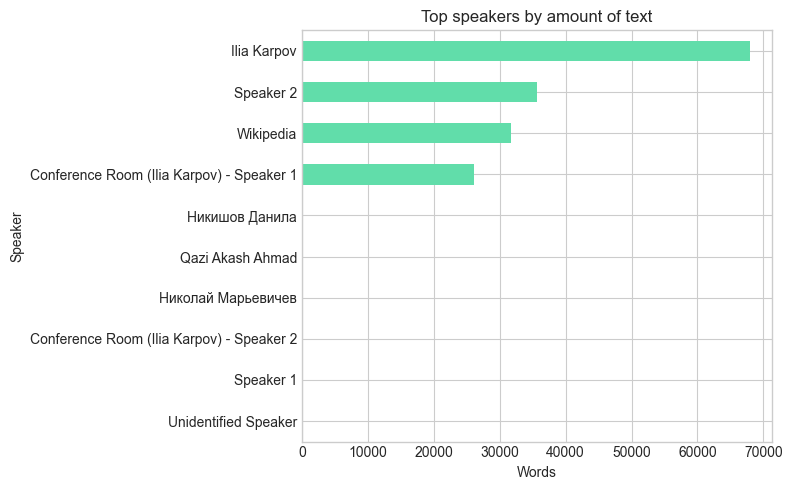

In [22]:
speaker_stats = (
    segments_df.groupby("speaker", as_index=False)
    .agg(segments=("document_id", "count"), words=("words", "sum"))
    .sort_values("words", ascending=False)
)

display(speaker_stats.head(10))

ax = speaker_stats.head(10).plot.barh(x="speaker", y="words", legend=False, figsize=(8, 5), color="#61DDAA")
ax.set_title("Top speakers by amount of text")
ax.set_xlabel("Words")
ax.set_ylabel("Speaker")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Text Cleaning and Chunking

For the knowledge graph we need smaller units than full lectures. I create chunks from speaker segments. Very short segments are removed because they usually do not contain meaningful relations.

In [23]:
def clean_text(text):
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

chunks = []
for _, row in segments_df.iterrows():
    text = clean_text(row["text"])
    sentences = re.split(r"(?<=[.!?])\s+", text)
    buffer = []
    buffer_words = 0
    chunk_no = 0

    for sentence in sentences:
        words = re.findall(r"[A-Za-zА-Яа-я0-9_]+", sentence)
        if not words:
            continue
        buffer.append(sentence)
        buffer_words += len(words)

        if buffer_words >= 120:
            chunks.append({
                "chunk_id": f"{row['document_id']}_chunk_{chunk_no:02d}",
                "corpus": row["corpus"],
                "source_file": row["source_file"],
                "speaker": row["speaker"],
                "text": " ".join(buffer),
                "words": buffer_words,
            })
            buffer = []
            buffer_words = 0
            chunk_no += 1

    if buffer_words >= 30:
        chunks.append({
            "chunk_id": f"{row['document_id']}_chunk_{chunk_no:02d}",
            "corpus": row["corpus"],
            "source_file": row["source_file"],
            "speaker": row["speaker"],
            "text": " ".join(buffer),
            "words": buffer_words,
        })

chunks_df = pd.DataFrame(chunks)
chunks_df.head()


,chunk_id,corpus,source_file,speaker,text,words
0,01_transcript_000_chunk_00,course_transcripts,01_transcript.md,Ilia Karpov,"Okay, I guess we may start for today. Hello ev...",69
1,01_transcript_002_chunk_00,course_transcripts,01_transcript.md,Ilia Karpov,"Thank you. Okay. Because the previous year, we...",123
2,01_transcript_002_chunk_01,course_transcripts,01_transcript.md,Ilia Karpov,And I'm also doing a pretty large list of proj...,122
3,01_transcript_002_chunk_02,course_transcripts,01_transcript.md,Ilia Karpov,You'll have an option during the consulting ho...,120
4,01_transcript_002_chunk_03,course_transcripts,01_transcript.md,Ilia Karpov,So I am more likely like a listener in the NLP...,131


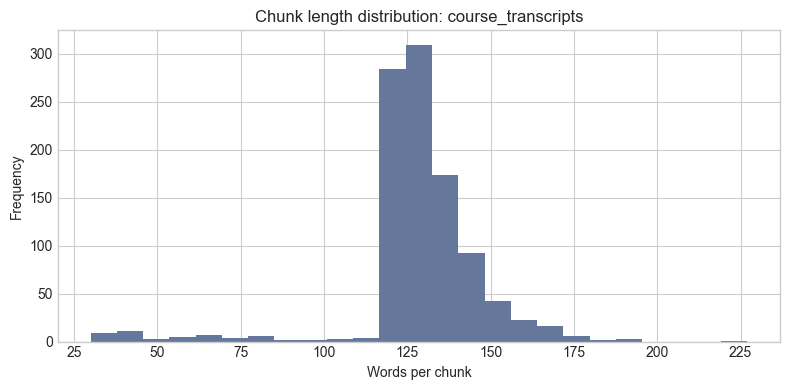

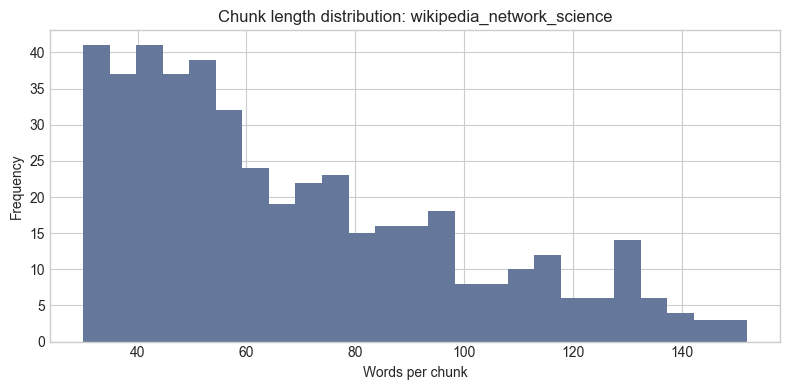

,count,mean,std,min,25%,50%,75%,max
corpus,,,,,,,,
course_transcripts,1007.0,128.617676,20.679217,30.0,123.0,128.0,137.0,227.0
wikipedia_network_science,460.0,68.536957,30.199279,30.0,44.0,60.0,87.0,152.0


In [24]:
for corpus, part in chunks_df.groupby("corpus"):
    ax = part["words"].plot.hist(bins=25, figsize=(8, 4), color="#65789B")
    ax.set_title(f"Chunk length distribution: {corpus}")
    ax.set_xlabel("Words per chunk")
    plt.tight_layout()
    plt.show()

chunks_df.groupby("corpus")["words"].describe()


Transcript chunks are longer on average, because lectures contain long explanations. Wikipedia chunks are shorter and more compact. For knowledge graph extraction this matters: transcripts may contain richer context, but Wikipedia should give less noisy entity candidates.

## 5. Vocabulary and Topic Signals

Before entity extraction, I check frequent meaningful words and phrases. This helps to understand whether the corpus really contains graph-related concepts.

course_transcripts


,word,count
0,node,699
1,nodes,656
2,graph,618
3,like,504
4,need,318
5,model,276
6,network,272
7,information,262
8,likely,255
9,list,228


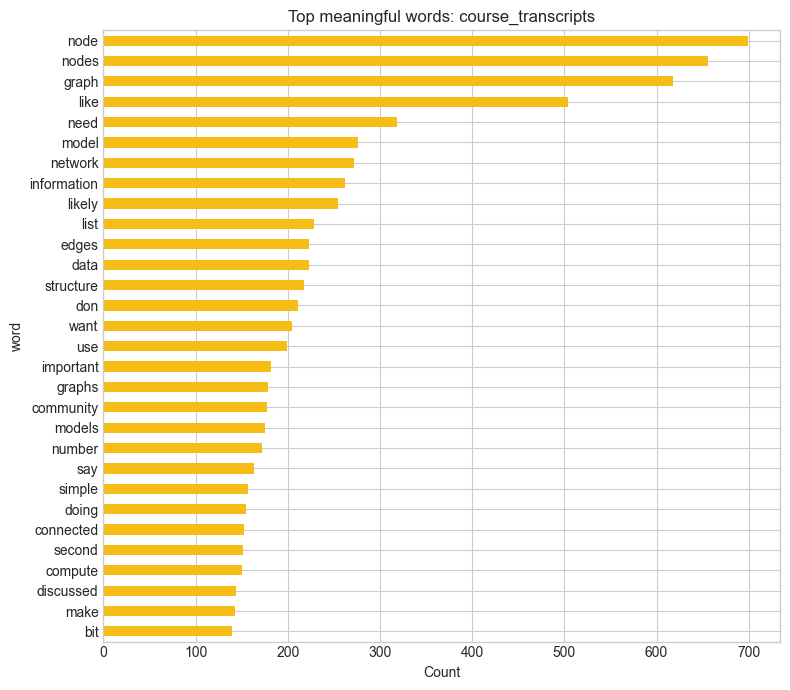

wikipedia_network_science


,word,count
0,graph,352
1,network,281
2,nodes,183
3,graphs,157
4,networks,148
5,used,125
6,centrality,124
7,pagerank,123
8,node,115
9,edges,105


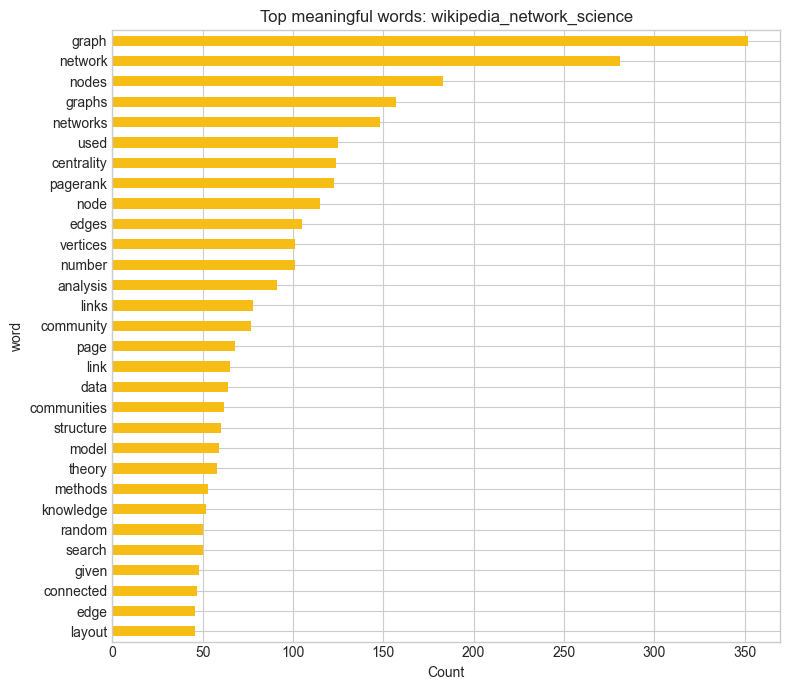

In [25]:
custom_stopwords = {
    "yeah", "okay", "ok", "sorry", "guess", "just", "really", "pretty", "thing", "things",
    "something", "someone", "everyone", "maybe", "probably", "actually", "basically", "obviously",
    "lecture", "course", "class", "today", "guys", "student", "students", "professor", "teacher",
    "question", "answer", "example", "examples", "problem", "problems", "idea", "ideas", "point",
    "case", "cases", "part", "parts", "kind", "type", "types", "way", "ways", "time", "times",
    "good", "bad", "better", "best", "large", "small", "different", "certain", "general",
    "speaker", "generally", "usually", "let", "yes", "thank", "thanks", "talking", "secondary",
    "online", "social", "come", "lots", "google", "googled", "russian",
}

stopwords = set(ENGLISH_STOP_WORDS) | custom_stopwords

# If noisy words appear in the graph later, add them to custom_stopwords above and rerun the notebook.
top_words_by_corpus = {}

for corpus, part in chunks_df.groupby("corpus"):
    tokens = []
    for text in part["text"]:
        tokens.extend(t.lower() for t in re.findall(r"[A-Za-z][A-Za-z\-]{2,}", text))

    word_counts = Counter(t for t in tokens if t not in stopwords)
    top_words = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])
    top_words_by_corpus[corpus] = top_words

    print(corpus)
    display(top_words)

    ax = top_words.sort_values("count").plot.barh(x="word", y="count", legend=False, figsize=(8, 7), color="#F6BD16")
    ax.set_title(f"Top meaningful words: {corpus}")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()


Both corpora contain the expected graph vocabulary: nodes, graph, network, edges, community, centrality, PageRank and related terms. This is a good sign: the selected datasets are not random text collections, they are actually suitable for building a network-science knowledge graph.

## 6. First Entity Candidates

For the final pipeline we can use a normal NLP model, but for EDA a transparent rule-based draft is useful. Here I combine two sources of entity candidates:

- known graph/SNA terms from the course context;
- capitalized multi-word expressions from the transcripts.

In [26]:
known_terms = [
    "NetworkX", "Gephi", "PageRank", "centrality", "degree centrality", "betweenness centrality",
    "community detection", "connected component", "giant connected component", "node2vec",
    "link prediction", "negative sampling", "Graph Neural Network", "GNN", "embedding",
    "Erdos-Renyi", "Watts-Strogatz", "Barabasi-Albert", "preferential attachment",
    "Jaccard coefficient", "Adamic-Adar", "Karate Club", "VK", "LinkedIn", "Facebook",
    "Twitter", "recommendation", "classification", "knowledge graph", "RAG", "named entity recognition",
    "relation extraction", "Wikipedia", "graph theory", "network science",
]

entity_aliases = {
    "gnn": "Graph Neural Network",
    "graph neural networks": "Graph Neural Network",
    "pagerank": "PageRank",
    "page rank": "PageRank",
    "networkx": "NetworkX",
    "node2vec": "node2vec",
    "rag": "RAG",
    "vk": "VK",
}


def normalize_entity(candidate):
    candidate = re.sub(r"\s+", " ", candidate.strip())
    candidate = candidate.strip(".,:;!?()[]{}\"'")
    if not candidate:
        return None

    words = re.findall(r"[A-Za-z][A-Za-z\-]*", candidate)
    if not words:
        return None

    lowered_words = [w.lower() for w in words]
    if all(w in stopwords for w in lowered_words):
        return None

    lowered = " ".join(lowered_words)
    if lowered in stopwords:
        return None
    if lowered in entity_aliases:
        return entity_aliases[lowered]

    if len(words) == 1 and lowered_words[0] in stopwords:
        return None
    if len(words) == 1 and len(words[0]) < 3:
        return None

    return candidate


entity_counts_by_corpus = {}
chunk_entities_by_corpus = {}
entity_tables = []

for corpus, part in chunks_df.groupby("corpus"):
    entity_counts = Counter()
    chunk_entities = defaultdict(set)

    for _, row in part.iterrows():
        text = row["text"]
        chunk_id = row["chunk_id"]

        for term in known_terms:
            if re.search(rf"\b{re.escape(term)}\b", text, flags=re.IGNORECASE):
                normalized = normalize_entity(term)
                if normalized:
                    entity_counts[normalized] += 1
                    chunk_entities[chunk_id].add(normalized)

        candidates = re.findall(r"\b(?:[A-Z][a-z]+|[A-Z]{2,})(?:\s+(?:[A-Z][a-z]+|[A-Z]{2,}))*\b", text)
        for candidate in candidates:
            normalized = normalize_entity(candidate)
            if not normalized:
                continue
            entity_counts[normalized] += 1
            chunk_entities[chunk_id].add(normalized)

    corpus_entities = pd.DataFrame(entity_counts.most_common(), columns=["entity", "chunk_mentions"])
    corpus_entities.insert(0, "corpus", corpus)
    entity_counts_by_corpus[corpus] = entity_counts
    chunk_entities_by_corpus[corpus] = chunk_entities
    entity_tables.append(corpus_entities)

    print(corpus)
    display(corpus_entities.head(30))

entities_df = pd.concat(entity_tables, ignore_index=True) if entity_tables else pd.DataFrame(columns=["corpus", "entity", "chunk_mentions"])


course_transcripts


,corpus,entity,chunk_mentions
0,course_transcripts,embedding,65
1,course_transcripts,Graph Neural Network,47
2,course_transcripts,Ilia Karpov,45
3,course_transcripts,classification,44
4,course_transcripts,Conference Room,44
5,course_transcripts,community detection,32
6,course_transcripts,Facebook,31
7,course_transcripts,recommendation,28
8,course_transcripts,PageRank,27
9,course_transcripts,Python,26


wikipedia_network_science


,corpus,entity,chunk_mentions
0,wikipedia_network_science,PageRank,59
1,wikipedia_network_science,centrality,56
2,wikipedia_network_science,graph theory,29
3,wikipedia_network_science,NetworkX,27
4,wikipedia_network_science,NER,18
5,wikipedia_network_science,SNA,14
6,wikipedia_network_science,community detection,14
7,wikipedia_network_science,knowledge graph,14
8,wikipedia_network_science,Graph Neural Network,14
9,wikipedia_network_science,betweenness centrality,13


## 7. Preliminary Knowledge Graph

This is not the final graph yet. It is a draft graph for EDA. It contains:

- document/chunk nodes;
- entity candidate nodes;
- `MENTIONS` edges from chunks to entities;
- `CO_OCCURS_WITH` edges between entities inside the same chunk.

### Why these graph checks are used

For KG EDA, graph construction is not enough. We also need to check whether the graph is useful and interpretable.

In [27]:
graphs = {}
graph_stats_rows = []

for corpus, part in chunks_df.groupby("corpus"):
    G = nx.Graph()
    chunk_entities = chunk_entities_by_corpus.get(corpus, {})

    for _, row in part.iterrows():
        chunk_id = row["chunk_id"]
        G.add_node(chunk_id, node_type="Document", corpus=row["corpus"], source_file=row["source_file"], speaker=row["speaker"])

        entities = sorted(chunk_entities.get(chunk_id, []))
        for entity in entities:
            G.add_node(entity, node_type="Entity", corpus=corpus)
            G.add_edge(chunk_id, entity, edge_type="MENTIONS", weight=1)

        for i, left in enumerate(entities):
            for right in entities[i + 1:]:
                if G.has_edge(left, right):
                    G[left][right]["weight"] += 1
                else:
                    G.add_edge(left, right, edge_type="CO_OCCURS_WITH", weight=1)

    graphs[corpus] = G
    largest_component = len(max(nx.connected_components(G), key=len)) if G.number_of_nodes() else 0
    graph_stats_rows.append({
        "corpus": corpus,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "components": nx.number_connected_components(G) if G.number_of_nodes() else 0,
        "largest_component_nodes": largest_component,
        "density": nx.density(G),
    })

graph_stats_df = pd.DataFrame(graph_stats_rows)
graph_stats_df


,corpus,nodes,edges,components,largest_component_nodes,density
0,course_transcripts,1783,3239,392,1169,0.002039
1,wikipedia_network_science,1283,4237,118,986,0.005152


Both corpora produce a large connected component, so the extracted entities are not just isolated keywords. Wikipedia has higher density and fewer components, which is expected for cleaner encyclopedic text. The transcript graph is more fragmented because spoken lecture text contains more side remarks and noisy phrases.

In [28]:
centrality_tables = []
entity_subgraphs = {}

for corpus, G in graphs.items():
    entity_nodes = [node for node, data in G.nodes(data=True) if data.get("node_type") == "Entity"]
    entity_subgraph = G.subgraph(entity_nodes).copy()
    entity_subgraphs[corpus] = entity_subgraph

    degree = dict(entity_subgraph.degree(weight="weight"))
    pagerank = nx.pagerank(entity_subgraph, weight="weight") if entity_subgraph.number_of_nodes() else {}

    central_entities = pd.DataFrame({
        "corpus": corpus,
        "entity": list(entity_subgraph.nodes()),
        "weighted_degree": [degree.get(node, 0) for node in entity_subgraph.nodes()],
        "pagerank": [pagerank.get(node, 0) for node in entity_subgraph.nodes()],
    }).sort_values(["pagerank", "weighted_degree"], ascending=False)

    centrality_tables.append(central_entities)

    print(corpus)
    display(central_entities.head(25))

central_entities_all = pd.concat(centrality_tables, ignore_index=True) if centrality_tables else pd.DataFrame()


course_transcripts


,corpus,entity,weighted_degree,pagerank
671,course_transcripts,embedding,91,0.018981
201,course_transcripts,classification,92,0.018861
50,course_transcripts,Ilia Karpov,73,0.012816
154,course_transcripts,Conference Room,68,0.011894
59,course_transcripts,recommendation,50,0.010706
179,course_transcripts,Graph Neural Network,45,0.009374
305,course_transcripts,GCN,41,0.009025
635,course_transcripts,link prediction,44,0.008738
618,course_transcripts,PageRank,40,0.008613
445,course_transcripts,centrality,42,0.008600


wikipedia_network_science


,corpus,entity,weighted_degree,pagerank
54,wikipedia_network_science,PageRank,158,0.021371
37,wikipedia_network_science,centrality,157,0.021298
1,wikipedia_network_science,graph theory,94,0.014502
720,wikipedia_network_science,NetworkX,49,0.007908
767,wikipedia_network_science,NER,37,0.007387
45,wikipedia_network_science,betweenness centrality,44,0.005819
55,wikipedia_network_science,community detection,28,0.005643
153,wikipedia_network_science,Retrieved,45,0.004625
109,wikipedia_network_science,knowledge graph,33,0.004623
561,wikipedia_network_science,classification,28,0.004527


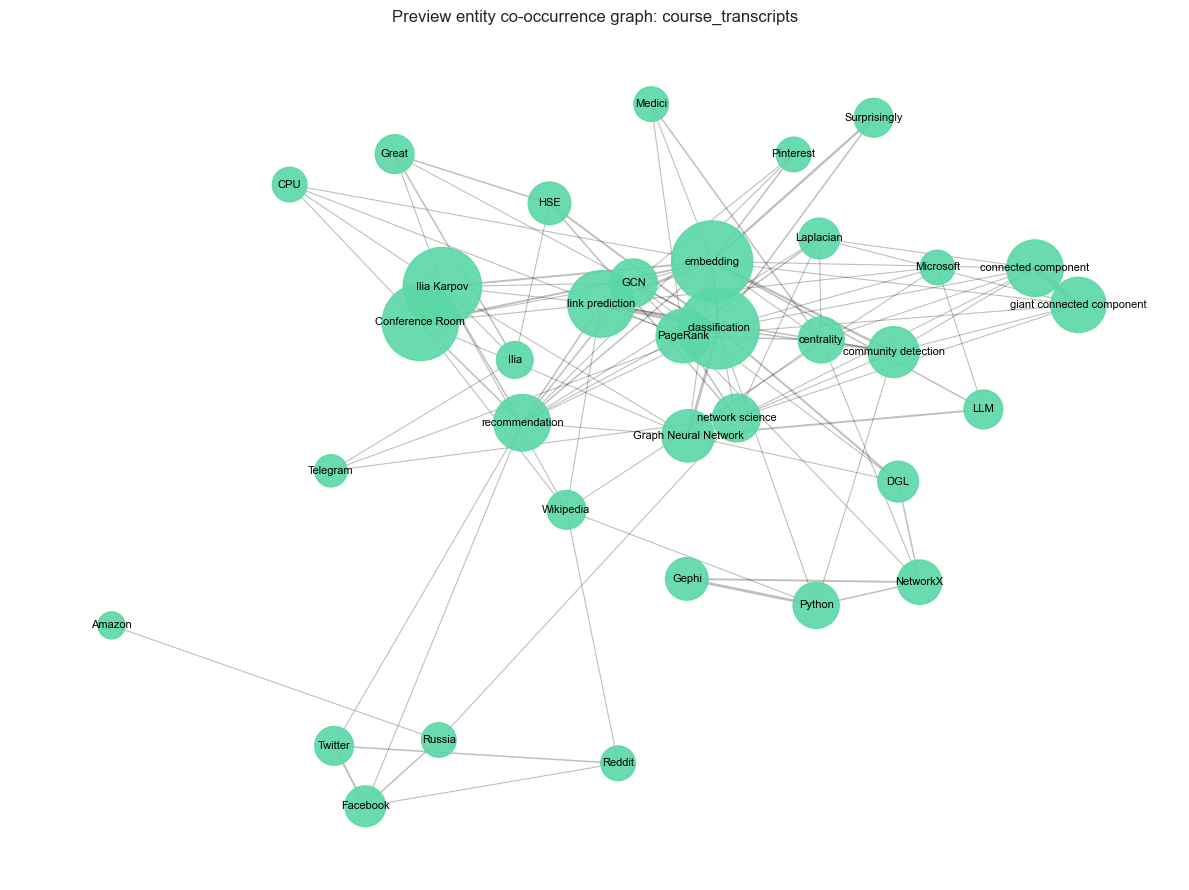

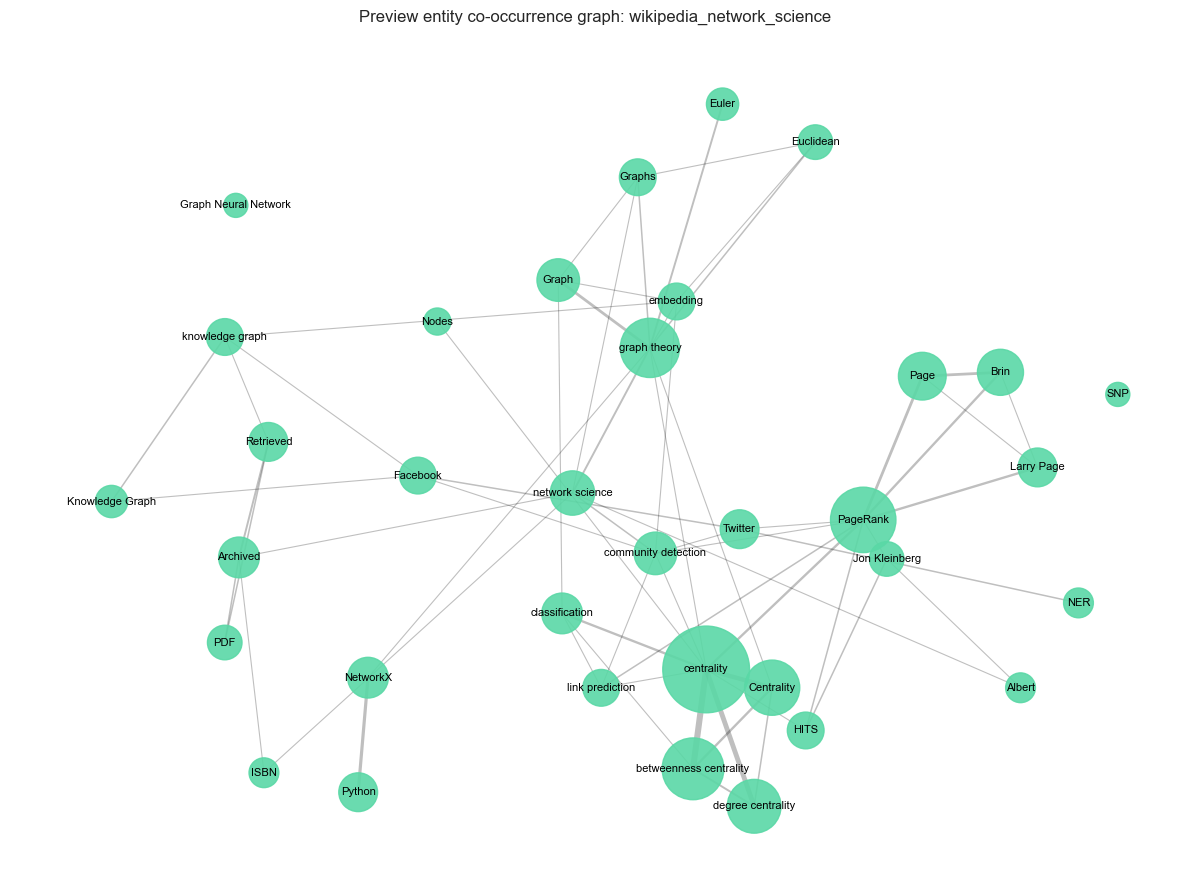

In [29]:
for corpus, central_entities in central_entities_all.groupby("corpus"):
    entity_subgraph = entity_subgraphs[corpus]
    top_graph_nodes = central_entities.head(35)["entity"].tolist()
    preview = entity_subgraph.subgraph(top_graph_nodes).copy()

    plt.figure(figsize=(12, 9))
    pos = nx.spring_layout(preview, seed=42, k=0.9)
    node_sizes = [300 + 80 * preview.degree(node, weight="weight") for node in preview.nodes()]
    edge_widths = [0.5 + 0.3 * preview[u][v].get("weight", 1) for u, v in preview.edges()]

    nx.draw_networkx_edges(preview, pos, alpha=0.25, width=edge_widths)
    nx.draw_networkx_nodes(preview, pos, node_size=node_sizes, node_color="#5AD8A6", alpha=0.9)
    nx.draw_networkx_labels(preview, pos, font_size=8)

    plt.title(f"Preview entity co-occurrence graph: {corpus}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


The graph previews should be read as diagnostic pictures, not final knowledge graphs. If generic words become central nodes, they should be added to custom stopwords or normalized. The useful result here is that central graph concepts start forming visible clusters around methods, tools, and applications.

## 8. Manual Evaluation Draft

The final project should include a small manual check. For the draft, I sample entity candidates and co-occurrence relations. Later these rows can be marked manually as correct/incorrect.

In [30]:
entity_eval_samples = []

for corpus, part in entities_df.groupby("corpus"):
    sample = part.head(100).sample(min(30, len(part)), random_state=42).copy()
    sample["manual_is_correct"] = ""
    entity_eval_samples.append(sample)
    print(corpus)
    display(sample)

entity_eval_sample = pd.concat(entity_eval_samples, ignore_index=True) if entity_eval_samples else pd.DataFrame()


course_transcripts


,corpus,entity,chunk_mentions,manual_is_correct
83,course_transcripts,Kaggle,4,
53,course_transcripts,GPT,6,
70,course_transcripts,Yep,5,
45,course_transcripts,Does,7,
44,course_transcripts,Karate,7,
39,course_transcripts,Ilia,7,
22,course_transcripts,Gurobi,12,
80,course_transcripts,Stanford,4,
10,course_transcripts,Gephi,26,
0,course_transcripts,embedding,65,


wikipedia_network_science


,corpus,entity,chunk_mentions,manual_is_correct
859,wikipedia_network_science,Ford,3,
829,wikipedia_network_science,EDA,4,
846,wikipedia_network_science,Betweenness,3,
821,wikipedia_network_science,Archived,4,
820,wikipedia_network_science,ISBN,4,
815,wikipedia_network_science,Finding,4,
798,wikipedia_network_science,Python,9,
856,wikipedia_network_science,Edges,3,
786,wikipedia_network_science,link prediction,12,
776,wikipedia_network_science,PageRank,59,


In [31]:
relation_tables = []
relation_eval_samples = []

for corpus, entity_subgraph in entity_subgraphs.items():
    relation_rows = []
    for left, right, data in entity_subgraph.edges(data=True):
        relation_rows.append({
            "corpus": corpus,
            "source": left,
            "target": right,
            "relation": data.get("edge_type", "CO_OCCURS_WITH"),
            "weight": data.get("weight", 1),
        })

    relations_df = pd.DataFrame(relation_rows).sort_values("weight", ascending=False)
    relation_tables.append(relations_df)

    sample = relations_df.head(200).sample(min(30, len(relations_df)), random_state=42).copy()
    sample["manual_is_correct"] = ""
    relation_eval_samples.append(sample)

    print(corpus)
    display(sample)

relations_all = pd.concat(relation_tables, ignore_index=True) if relation_tables else pd.DataFrame()
relation_eval_sample = pd.concat(relation_eval_samples, ignore_index=True) if relation_eval_samples else pd.DataFrame()


course_transcripts


,corpus,source,target,relation,weight,manual_is_correct
1044,course_transcripts,GAT,GAN,CO_OCCURS_WITH,1,
630,course_transcripts,Graph Neural Network,LLM,CO_OCCURS_WITH,3,
1076,course_transcripts,Ilia,Danil,CO_OCCURS_WITH,2,
1109,course_transcripts,Steam,Microsoft,CO_OCCURS_WITH,1,
1028,course_transcripts,Node,Hello,CO_OCCURS_WITH,1,
996,course_transcripts,USSR,Mexico,CO_OCCURS_WITH,1,
676,course_transcripts,connected component,Giant Connected Component,CO_OCCURS_WITH,2,
1147,course_transcripts,Gephi,Aura,CO_OCCURS_WITH,1,
1142,course_transcripts,Gephi,Gaff,CO_OCCURS_WITH,1,
476,course_transcripts,node2vec,embedding,CO_OCCURS_WITH,2,


wikipedia_network_science


,corpus,source,target,relation,weight,manual_is_correct
410,wikipedia_network_science,degree centrality,Degree,CO_OCCURS_WITH,2,
330,wikipedia_network_science,centrality,Percolation,CO_OCCURS_WITH,4,
1047,wikipedia_network_science,Euler,Leonhard Euler,CO_OCCURS_WITH,2,
1862,wikipedia_network_science,Bernd,Victor,CO_OCCURS_WITH,1,
1937,wikipedia_network_science,Formally,Information,CO_OCCURS_WITH,1,
425,wikipedia_network_science,PageRank,link prediction,CO_OCCURS_WITH,2,
1958,wikipedia_network_science,HITS,Marchiori,CO_OCCURS_WITH,2,
1880,wikipedia_network_science,IAS,Reiner,CO_OCCURS_WITH,1,
1905,wikipedia_network_science,April,United States,CO_OCCURS_WITH,1,
487,wikipedia_network_science,PageRank,Toolbar,CO_OCCURS_WITH,2,


## 9. EDA Summary

The EDA compared two raw text corpora for knowledge graph construction: local course transcripts and Wikipedia pages about network science.

The course transcripts are the better main dataset for this project because they are directly connected to the course and contain explanations, examples, tools, and applications discussed by the lecturer. Their disadvantage is noise: spoken text creates filler words and unstable entity candidates.

Wikipedia is a useful second dataset and baseline. It is cleaner, more compact, and creates a denser graph, but it is less original and less connected to the course context.

Final project direction: use course transcripts as the main corpus, use Wikipedia as a comparison corpus, keep entity extraction transparent, and evaluate graph quality through centrality, connected components, visualization, and manual precision checks.

In [32]:
eda_summary = {
    "corpora": by_corpus.to_dict(orient="records"),
    "segments": int(len(segments_df)),
    "chunks": int(len(chunks_df)),
    "entity_candidates_by_corpus": entities_df.groupby("corpus")["entity"].count().to_dict(),
    "graph_stats_by_corpus": graph_stats_df.to_dict(orient="records"),
    "top_entities_by_pagerank": {
        corpus: part.head(20).to_dict(orient="records")
        for corpus, part in central_entities_all.groupby("corpus")
    },
}

eda_summary


{'corpora': [{'corpus': 'course_transcripts',
   'source_files': 8,
   'segments': 111,
   'words': 130226},
  {'corpus': 'wikipedia_network_science',
   'source_files': 15,
   'segments': 447,
   'words': 31742}],
 'segments': 558,
 'chunks': 1467,
 'entity_candidates_by_corpus': {'course_transcripts': 776,
  'wikipedia_network_science': 823},
 'graph_stats_by_corpus': [{'corpus': 'course_transcripts',
   'nodes': 1783,
   'edges': 3239,
   'components': 392,
   'largest_component_nodes': 1169,
   'density': 0.002038834156987083},
  {'corpus': 'wikipedia_network_science',
   'nodes': 1283,
   'edges': 4237,
   'components': 118,
   'largest_component_nodes': 986,
   'density': 0.0051519753697396534}],
 'top_entities_by_pagerank': {'course_transcripts': [{'corpus': 'course_transcripts',
    'entity': 'embedding',
    'weighted_degree': 91,
    'pagerank': 0.018981402208942264},
   {'corpus': 'course_transcripts',
    'entity': 'classification',
    'weighted_degree': 92,
    'pagerank'